In [46]:
# Manipuilacion y calculos 
import pandas as pd
import numpy as np
# Procesamiento del lenguaje Natural 
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import WordPunctTokenizer



#Modelado 

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix , accuracy_score , ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# Vizualizar datos
import matplotlib
import matplotlib.pyplot as plt

### Carga de datos y utilidades

In [2]:
nltk.download("stopwords")
wpt = WordPunctTokenizer()
stop_words = stopwords.words("spanish")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ovill\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
path = r"C:\Users\ovill\OneDrive\Escritorio\corpus_etiquetas.csv"
data = pd.read_csv(path)
data.shape

(262, 6)

In [4]:
data.sample(10).head(3)

,Sección,Categoría,Titular,Link,Cuerpo,binaria
162,País,País,Paraguayo expondrá en la Notre Dame de EEUU,https://www.ultimahora.com/paraguayo-expondra-...,Paraguayo expondrá en la Notre Dame de EEUU El...,1
84,Arte,Arte y Espectáculos,Leal y Pedro Undercover se emitirán por Telefu...,https://www.ultimahora.com/leal-y-pedro-underc...,Leal y Pedro Undercover se emitirán por Telefu...,0
142,Economía,Economía,PGN 2026: Ministerio de la Mujer pide presupue...,https://www.ultimahora.com/pgn-2026-ministerio...,PGN 2026: Ministerio de la Mujer pide presupue...,1


### Funciones

In [ ]:
def normalizar_documento(doc):
    """
    Normaliza un documento en español:
    - Minusculas
    - Elimina caracteres especiales excepto acentos y ñ
    - Tokeniza
    - Quita stopwords
    - Reconstruye el documento
    """
    # minusculas
    doc = doc.lower()
    # eliminar caracteres especiales excepto acentos y ñ
    doc = re.sub(r'[^a-záéíóúüñ\s]', '', doc)
    doc = doc.strip()
    # tokenizar
    tokens = wpt.tokenize(doc)
    # quitar stopwords
    tokens_filtrados = [t for t in tokens if t not in stop_words]
    # reconstruir documento
    doc = ' '.join(tokens_filtrados)
    return doc

def normalizar_documento_con_stopwords(doc):
    """
    Normaliza un documento en español pero CONSERVA los stopwords.
    - Minusculas
    - Elimina caracteres especiales excepto acentos y ñ
    - Tokeniza
    - Reconstruye el documento
    """
    # minusculas
    doc = doc.lower()
    # eliminar caracteres especiales excepto acentos y ñ
    doc = re.sub(r'[^a-záéíóúüñ\s]', '', doc)
    doc = doc.strip()
    # tokenizar
    tokens = wpt.tokenize(doc)
    
    doc = ' '.join(tokens)
    return doc

In [33]:
def plot_radar_chart(data, metrics, title):
    N = len(metrics)
    theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
    theta = np.concatenate([theta, [theta[0]]])
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
    
    ax.set_title(title, y=1.1, fontsize=20)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    color_palette = ['#339F00', '#0500FF', '#FF9900', '#FF00DE', '#9CDADB']
        
    for idx, (i, row) in enumerate(data.iterrows()):
        values = row[metrics].values.flatten().tolist()
        values = values + [values[0]]
        ax.plot(theta, values, linewidth=1.5, linestyle='solid', label=row['Region'], marker='o', markersize=8, color=color_palette[idx % len(color_palette)])
        ax.fill(theta, values, alpha=0.25, color=color_palette[idx % len(color_palette)])
    
    # Ajuste: etiquetas de 0 a 1 para nuestras métricas
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
    ax.set_ylim(0, 1) # Asegurar que el eje va de 0 a 1

    # Reordenar las etiquetas de los ejes para que no se superpongan
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(metrics, size=12)
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1)) 
    plt.show()

In [25]:
def metrics_model(modelo , X , Y):
    y_pred_1 = modelo.predict(X)
    y_proba_1 = modelo.predict_proba(X)[:, 1]
    report_1 = classification_report(Y, y_pred_1, output_dict=True)
    metrics_1 = {
        "Accuracy": accuracy_score(Y, y_pred_1),
        "ROC AUC": roc_auc_score(Y, y_proba_1),
        "Precision": report_1['1']['precision'],
        "Recall": report_1['1']['recall'],
        "F1-Score": report_1['1']['f1-score']
    }
 
    return metrics_1


### Preprosesamiento

In [6]:
data['cuerpo_procesado'] = data['Cuerpo'].apply(normalizar_documento)
data['cuerpo_procesado_wsw'] = data['Cuerpo'].apply(normalizar_documento_con_stopwords)
data['binaria'] = data['binaria'].astype(int)

In [7]:
## Eliminando Stop Words 

X = data['cuerpo_procesado']
y = data['binaria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    random_state=777,  
    stratify=y        
)

## Dejando Stop Words 

X = data['cuerpo_procesado_wsw']
y = data['binaria']

X_train_wsw, X_test_sws, _, _ = train_test_split(
    X, y,
    test_size=0.2,    
    random_state=777,  
    stratify=y        
)

In [8]:
max_evals = 2000

### Modelado

### TF-IDF / Stop Words

En este punto decido que es mejor buscar hiperparametros usando un metodo bayesiano por lo que describo cada parametro considerado con la finalidad de maximizar el rendimiento del modelo (medido por ROC AUC usando CV). 

**TF-IDF**
* ngram_range : Define el rango de n-gramas (secuencias de palabras) que se usarán como características.
* min_df : Establece el número mínimo de documentos en los que una palabra (o n-grama) debe aparecer para ser considerada como característica
* max_df : Define el umbral máximo de frecuencia de documentos para incluir un término

** Maquina de soporte vectorial**

* C: Controla la inversa de la regularización. Valores más pequeños de C implican una regularización más fuerte, lo que reduce el riesgo de sobreajuste pero puede limitar la capacidad del modelo para capturar patrones complejos.
* kernel: Define la función de kernel utilizada para transformar los datos a un espacio de mayor dimensión

**Regresion Logistica**

* penalty: Especifica el tipo de regularización: l1 (Lasso) o l2 (Ridge)

**RandomForest** 

* n_estimators: Define el número de árboles en el bosque.
* max_depth :   Limita la profundidad máxima de cada árbol
* min_samples_leaf : Especifica el número mínimo de muestras requeridas en una hoja del árbol

In [9]:
space = {
    # Parámetros del Vectorizador (comunes a todos los modelos)
    'vectorizer': {
        'ngram_range': hp.choice('ngram_range', [(1, 1), (1, 2) ,(1,3)]),
        'min_df': hp.choice('min_df', [ 2, 3, 5]),
        'max_df': hp.uniform('max_df', 0.3, 1.0),
    },
    # Elección del tipo de clasificador y sus parámetros específicos
    'classifier': hp.choice('classifier_type', [
        {
            'model': 'LogisticRegression',
            'params': {
                'C': hp.loguniform('lr_C', np.log(0.01), np.log(100)),
                'penalty': hp.choice('lr_penalty', ['l1', 'l2']),
                'solver': 'liblinear' # Requerido para l1/l2
            }
        },
        {
            'model': 'SVC',
            'params': {
                'C': hp.loguniform('svm_C', np.log(0.01), np.log(100)),
                'kernel': hp.choice('svm_kernel', ['linear', 'rbf']),
                'probability': True # ¡Esencial para roc_auc!
            }
        },
        {
            'model': 'RandomForest',
            'params': {
                'n_estimators': hp.quniform('rf_n_estimators', 50, 300, 25),
                'max_depth': hp.quniform('rf_max_depth', 3, 15, 1),
                'min_samples_leaf': hp.quniform('rf_min_samples_leaf', 5, 10, 1)
            }
        }
    ])
}

def objective(params , xtrain):
    
    # Construir el vectorizador con los parámetros dados
    vectorizer = TfidfVectorizer(**params['vectorizer'])
    
    # Seleccionar y construir el clasificador
    model_name = params['classifier']['model']
    model_params = params['classifier']['params']
    
    if model_name == 'LogisticRegression':
        classifier = LogisticRegression(**model_params)
    elif model_name == 'SVC':
        classifier = SVC(**model_params)
    elif model_name == 'RandomForest':
        # Los parámetros de RF deben ser enteros
        int_params = {k: int(v) for k, v in model_params.items()}
        classifier = RandomForestClassifier(**int_params, random_state=42)
        
    # Crear el pipeline completo
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])
    
    # Evaluar usando 'roc_auc'
    score = cross_val_score(pipeline, xtrain, y_train, cv=3, scoring='roc_auc', error_score='raise').mean()
    
    return {'loss': -score, 'status': STATUS_OK}

In [10]:
trials = Trials()
best_TF_stop = fmin(
    # La lambda recibe 'params' de fmin y llama data set con y sin stop words 
    fn=lambda params: objective(params, xtrain=X_train),
    space=space,
    algo=tpe.suggest,
    max_evals=max_evals, 
    trials=trials,
    rstate=np.random.default_rng(42)
)


100%|██████████| 2000/2000 [04:54<00:00,  6.79trial/s, best loss: -0.9746346843121038]


In [11]:
model_options = ['LogisticRegression', 'SVC', 'RandomForest']
ngram_options = [(1, 1), (1, 2) , (1,3)]
min_df_options = [1, 2, 3, 5]
penalty_options = ['l1', 'l2']
kernel_options = ['linear', 'rbf']

results = []
# Iterate through the trials to build the results table
for trial in trials.trials:
    # Get the parameters (indices and values) for this trial
    params = trial['misc']['vals']
    roc_auc = -trial['result']['loss']
    
    # Decode the indices using our predefined lists
    model_name = model_options[params['classifier_type'][0]]
    
    # Build a row with the trial's information, setting non-applicable params to None
    row = {
        'roc_auc_cv': roc_auc,
        'model': model_name,
        'ngram_range': ngram_options[params['ngram_range'][0]],
        'min_df': min_df_options[params['min_df'][0]],
        'max_df': params['max_df'][0],
        'lr_C': params.get('lr_C', [None])[0] if model_name == 'LogisticRegression' else None,
        'lr_penalty': penalty_options[params['lr_penalty'][0]] if model_name == 'LogisticRegression' else None,
        'svm_C': params.get('svm_C', [None])[0] if model_name == 'SVC' else None,
        'svm_kernel': kernel_options[params['svm_kernel'][0]] if model_name == 'SVC' else None,
        'rf_n_estimators': int(params.get('rf_n_estimators', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_max_depth': int(params.get('rf_max_depth', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_min_samples_leaf': int(params.get('rf_min_samples_leaf', [None])[0]) if model_name == 'RandomForest' else None
    }
    results.append(row)


In [12]:
results_df = pd.DataFrame(results).sort_values(by='roc_auc_cv', ascending=False).reset_index(drop=True)
# La mejor configuración es la primera fila de la tabla
best_config = results_df.iloc[0]
print("Mejor Configuración Encontrada:")
print(best_config)

Mejor Configuración Encontrada:
roc_auc_cv                       0.974635
model                  LogisticRegression
ngram_range                        (1, 1)
min_df                                  3
max_df                           0.496931
lr_C                            16.555257
lr_penalty                             l2
svm_C                                 NaN
svm_kernel                           None
rf_n_estimators                       NaN
rf_max_depth                          NaN
rf_min_samples_leaf                   NaN
Name: 0, dtype: object


In [13]:
# 1. Configurar el mejor vectorizador (TfidfVectorizer)
best_vectorizer = TfidfVectorizer(
    ngram_range=best_config['ngram_range'],
    min_df=int(best_config['min_df']),
    max_df=best_config['max_df']
)

best_model_name = best_config['model']

if best_model_name == 'LogisticRegression':
    best_classifier = LogisticRegression(C=best_config['lr_C'], penalty=best_config['lr_penalty'], solver='liblinear')
elif best_model_name == 'SVC':
    best_classifier = SVC(C=best_config['svm_C'], kernel=best_config['svm_kernel'], probability=True)
elif best_model_name == 'RandomForest':
    best_classifier = RandomForestClassifier(n_estimators=int(best_config['rf_n_estimators']), max_depth=int(best_config['rf_max_depth']), min_samples_leaf=int(best_config['rf_min_samples_leaf']), random_state=42)

final_TF_stop = Pipeline([
    ('vectorizer', best_vectorizer),
    ('classifier', best_classifier)
])

final_TF_stop.fit(X_train, y_train)


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [14]:
trials = Trials()
best_TF_stop = fmin(
    # La lambda recibe 'params' de fmin y llama data set con y sin stop words 
    fn=lambda params: objective(params, xtrain=X_train_wsw),
    space=space,
    algo=tpe.suggest,
    max_evals=max_evals, 
    trials=trials,
    rstate=np.random.default_rng(42)
)

model_options = ['LogisticRegression', 'SVC', 'RandomForest']
ngram_options = [(1, 1), (1, 2) , (1,3)]
min_df_options = [1, 2, 3, 5]
penalty_options = ['l1', 'l2']
kernel_options = ['linear', 'rbf']

results = []
# Iterate through the trials to build the results table
for trial in trials.trials:
    # Get the parameters (indices and values) for this trial
    params = trial['misc']['vals']
    roc_auc = -trial['result']['loss']
    
    # Decode the indices using our predefined lists
    model_name = model_options[params['classifier_type'][0]]
    
    # Build a row with the trial's information, setting non-applicable params to None
    row = {
        'roc_auc_cv': roc_auc,
        'model': model_name,
        'ngram_range': ngram_options[params['ngram_range'][0]],
        'min_df': min_df_options[params['min_df'][0]],
        'max_df': params['max_df'][0],
        'lr_C': params.get('lr_C', [None])[0] if model_name == 'LogisticRegression' else None,
        'lr_penalty': penalty_options[params['lr_penalty'][0]] if model_name == 'LogisticRegression' else None,
        'svm_C': params.get('svm_C', [None])[0] if model_name == 'SVC' else None,
        'svm_kernel': kernel_options[params['svm_kernel'][0]] if model_name == 'SVC' else None,
        'rf_n_estimators': int(params.get('rf_n_estimators', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_max_depth': int(params.get('rf_max_depth', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_min_samples_leaf': int(params.get('rf_min_samples_leaf', [None])[0]) if model_name == 'RandomForest' else None
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by='roc_auc_cv', ascending=False).reset_index(drop=True)
# La mejor configuración es la primera fila de la tabla
best_config = results_df.iloc[0]

best_vectorizer = TfidfVectorizer(
    ngram_range=best_config['ngram_range'],
    min_df=int(best_config['min_df']),
    max_df=best_config['max_df']
)

best_model_name = best_config['model']
# (La lógica para seleccionar y configurar el clasificador es la misma que antes)
if best_model_name == 'LogisticRegression':
    best_classifier = LogisticRegression(C=best_config['lr_C'], penalty=best_config['lr_penalty'], solver='liblinear')
elif best_model_name == 'SVC':
    best_classifier = SVC(C=best_config['svm_C'], kernel=best_config['svm_kernel'], probability=True)
elif best_model_name == 'RandomForest':
    best_classifier = RandomForestClassifier(n_estimators=int(best_config['rf_n_estimators']), max_depth=int(best_config['rf_max_depth']), min_samples_leaf=int(best_config['rf_min_samples_leaf']), random_state=42)

final_TF_ = Pipeline([
    ('vectorizer', best_vectorizer),
    ('classifier', best_classifier)
])

final_TF_.fit(X_train_wsw, y_train)

100%|██████████| 2000/2000 [11:50<00:00,  2.81trial/s, best loss: -0.9784656015555845]


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### Count Vectorizer 

In [15]:
space = {
    'vectorizer': {
        'ngram_range': hp.choice('ngram_range', [(1, 1), (1, 2), (1, 3)]),
        'min_df': hp.choice('min_df', [2, 3, 5]),
        'max_df': hp.uniform('max_df', 0.3, 1.0),
    },
    'classifier': hp.choice('classifier_type', [
        {
            'model': 'LogisticRegression',
            'params': {
                'C': hp.loguniform('lr_C', np.log(0.01), np.log(100)),
                'penalty': hp.choice('lr_penalty', ['l1', 'l2']),
                'solver': 'liblinear'
            }
        },
        {
            'model': 'SVC',
            'params': {
                'C': hp.loguniform('svm_C', np.log(0.01), np.log(100)),
                'kernel': hp.choice('svm_kernel', ['linear', 'rbf']),
                'probability': True
            }
        },
        {
            'model': 'RandomForest',
            'params': {
                'n_estimators': hp.quniform('rf_n_estimators', 50, 300, 25),
                'max_depth': hp.quniform('rf_max_depth', 3, 15, 1),
                'min_samples_leaf': hp.quniform('rf_min_samples_leaf', 5, 10, 1)
            }
        }
    ])
}

# --- 2. Función Objetivo (modificada para CountVectorizer) ---
def objective(params , xtrain):
    # Aquí es el cambio principal: usamos CountVectorizer
    vectorizer = CountVectorizer(**params['vectorizer'])
    
    model_name = params['classifier']['model']
    model_params = params['classifier']['params']
    
    if model_name == 'LogisticRegression':
        classifier = LogisticRegression(**model_params)
    elif model_name == 'SVC':
        classifier = SVC(**model_params)
    elif model_name == 'RandomForest':
        int_params = {k: int(v) for k, v in model_params.items()}
        classifier = RandomForestClassifier(**int_params, random_state=42)
        
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])
    
    score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='roc_auc').mean()
    
    return {'loss': -score, 'status': STATUS_OK}

In [16]:
trials = Trials()
best = fmin(
    fn=lambda params: objective(params, xtrain=X_train),
    space=space,
    algo=tpe.suggest,
    max_evals=max_evals,
    trials=trials,
    rstate=np.random.default_rng(42)
)


100%|██████████| 2000/2000 [09:21<00:00,  3.56trial/s, best loss: -0.9735318444995865]


In [ ]:
model_options = ['LogisticRegression', 'SVC', 'RandomForest']
ngram_options = [(1, 1), (1, 2) , (1,3)]
min_df_options = [1, 2, 3, 5]
penalty_options = ['l1', 'l2']
kernel_options = ['linear', 'rbf']

results = []

for trial in trials.trials:
    
    params = trial['misc']['vals']
    roc_auc = -trial['result']['loss']
    
    model_name = model_options[params['classifier_type'][0]]
    
    row = {
        'roc_auc_cv': roc_auc,
        'model': model_name,
        'ngram_range': ngram_options[params['ngram_range'][0]],
        'min_df': min_df_options[params['min_df'][0]],
        'max_df': params['max_df'][0],
        'lr_C': params.get('lr_C', [None])[0] if model_name == 'LogisticRegression' else None,
        'lr_penalty': penalty_options[params['lr_penalty'][0]] if model_name == 'LogisticRegression' else None,
        'svm_C': params.get('svm_C', [None])[0] if model_name == 'SVC' else None,
        'svm_kernel': kernel_options[params['svm_kernel'][0]] if model_name == 'SVC' else None,
        'rf_n_estimators': int(params.get('rf_n_estimators', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_max_depth': int(params.get('rf_max_depth', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_min_samples_leaf': int(params.get('rf_min_samples_leaf', [None])[0]) if model_name == 'RandomForest' else None
    }
    results.append(row)


In [18]:
results_df = pd.DataFrame(results).sort_values(by='roc_auc_cv', ascending=False).reset_index(drop=True)
# La mejor configuración es la primera fila de la tabla
best_config = results_df.iloc[0]

In [19]:
best_vectorizer = CountVectorizer(
    ngram_range=best_config['ngram_range'],
    min_df=int(best_config['min_df']),
    max_df=best_config['max_df']
)

# Configurar el mejor clasificador
best_model_name = best_config['model']
# (Esta lógica no cambia, ya que solo depende del nombre del modelo)
if best_model_name == 'LogisticRegression':
    best_classifier = LogisticRegression(C=best_config['lr_C'], penalty=best_config['lr_penalty'], solver='liblinear')
elif best_model_name == 'SVC':
    best_classifier = SVC(C=best_config['svm_C'], kernel=best_config['svm_kernel'], probability=True)
elif best_model_name == 'RandomForest':
    best_classifier = RandomForestClassifier(n_estimators=int(best_config['rf_n_estimators']), max_depth=int(best_config['rf_max_depth']), min_samples_leaf=int(best_config['rf_min_samples_leaf']), random_state=42)

# Construir el pipeline final
final_count_stop = Pipeline([
    ('vectorizer', best_vectorizer),
    ('classifier', best_classifier)
])

final_count_stop.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [21]:
trials = Trials()
best = fmin(
    fn=lambda params: objective(params, xtrain=X_train),
    space=space,
    algo=tpe.suggest,
    max_evals=max_evals,
    trials=trials,
    rstate=np.random.default_rng(42)
)

model_options = ['LogisticRegression', 'SVC', 'RandomForest']
ngram_options = [(1, 1), (1, 2) , (1,3)]
min_df_options = [1, 2, 3, 5]
penalty_options = ['l1', 'l2']
kernel_options = ['linear', 'rbf']

results = []
# Iterate through the trials to build the results table
for trial in trials.trials:
    # Get the parameters (indices and values) for this trial
    params = trial['misc']['vals']
    roc_auc = -trial['result']['loss']
    
    model_name = model_options[params['classifier_type'][0]]

    row = {
        'roc_auc_cv': roc_auc,
        'model': model_name,
        'ngram_range': ngram_options[params['ngram_range'][0]],
        'min_df': min_df_options[params['min_df'][0]],
        'max_df': params['max_df'][0],
        'lr_C': params.get('lr_C', [None])[0] if model_name == 'LogisticRegression' else None,
        'lr_penalty': penalty_options[params['lr_penalty'][0]] if model_name == 'LogisticRegression' else None,
        'svm_C': params.get('svm_C', [None])[0] if model_name == 'SVC' else None,
        'svm_kernel': kernel_options[params['svm_kernel'][0]] if model_name == 'SVC' else None,
        'rf_n_estimators': int(params.get('rf_n_estimators', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_max_depth': int(params.get('rf_max_depth', [None])[0]) if model_name == 'RandomForest' else None,
        'rf_min_samples_leaf': int(params.get('rf_min_samples_leaf', [None])[0]) if model_name == 'RandomForest' else None
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by='roc_auc_cv', ascending=False).reset_index(drop=True)

best_config = results_df.iloc[0]

best_vectorizer = CountVectorizer(
    ngram_range=best_config['ngram_range'],
    min_df=int(best_config['min_df']),
    max_df=best_config['max_df']
)

best_model_name = best_config['model']

if best_model_name == 'LogisticRegression':
    best_classifier = LogisticRegression(C=best_config['lr_C'], penalty=best_config['lr_penalty'], solver='liblinear')
elif best_model_name == 'SVC':
    best_classifier = SVC(C=best_config['svm_C'], kernel=best_config['svm_kernel'], probability=True)
elif best_model_name == 'RandomForest':
    best_classifier = RandomForestClassifier(n_estimators=int(best_config['rf_n_estimators']), max_depth=int(best_config['rf_max_depth']), min_samples_leaf=int(best_config['rf_min_samples_leaf']), random_state=42)

final_count_ = Pipeline([
    ('vectorizer', best_vectorizer),
    ('classifier', best_classifier)
])

final_count_.fit(X_train_wsw, y_train)

100%|██████████| 2000/2000 [09:05<00:00,  3.67trial/s, best loss: -0.9735318444995865]


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


**Modelos Finales**

* final_TF_stop :
* final_TF_ :
* final_count_stop :
* final_count_ :

### Evaluacion de Rendimiento

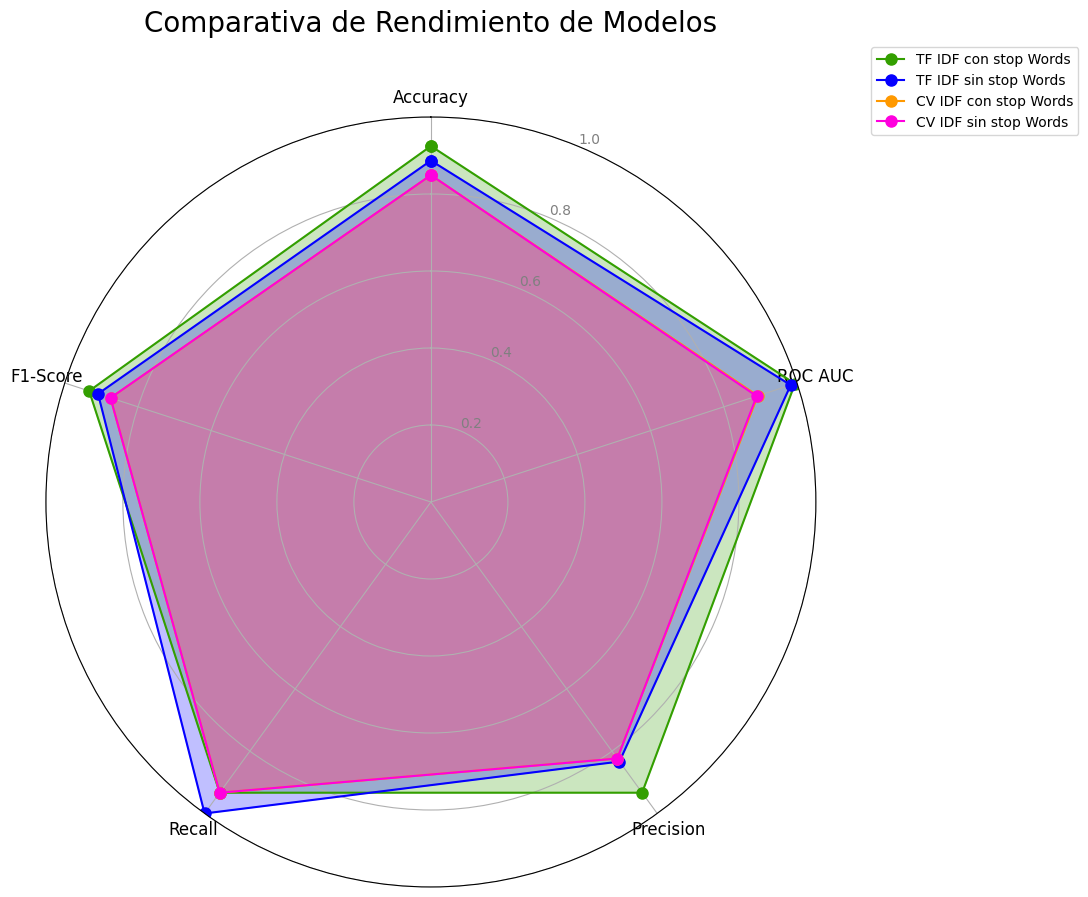

In [45]:
data_for_plot = [
    {'Region': 'TF IDF con stop Words', **metrics_model(final_TF_stop , X_test , y_test)},
    {'Region': 'TF IDF sin stop Words', **metrics_model(final_TF_ , X_test , y_test)},
     {'Region': 'CV IDF con stop Words', **metrics_model(final_count_stop , X_test , y_test)}, 
     {'Region': 'CV IDF sin stop Words', **metrics_model(final_count_ , X_test , y_test)},  
]

df_models = pd.DataFrame(data_for_plot)
metrics_to_plot = ['Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1-Score']
plot_radar_chart(df_models, metrics_to_plot, 'Comparativa de Rendimiento de Modelos')

### Conclusiones

Basado en los resultados de la optimización y su rendimiento, la conclusión es que el modelo más efectivo para esta tarea es una Regresión Logística combinada con un preprocesamiento de texto que filtra el vocabulario de manera significativa.

El mejor modelo encontrado es un pipeline que consiste en:

* Un TfidfVectorizer ngram_range=(1, 1) min_df=3  y max_df=0.50

* Un clasificador de LogisticRegression con parametros C=16.56 

El rendimiento obtenido durante la validación cruzada fue la siguiente:  

Exactitud (Accuracy): 0.9245
Área Bajo la Curva ROC (AUC): 0.9942

 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        23
           1       0.93      0.93      0.93        30

    accuracy                           0.92        53
   macro avg       0.92      0.92      0.92        53
weighted avg       0.92      0.92      0.92        53

Matriz de Confusión:


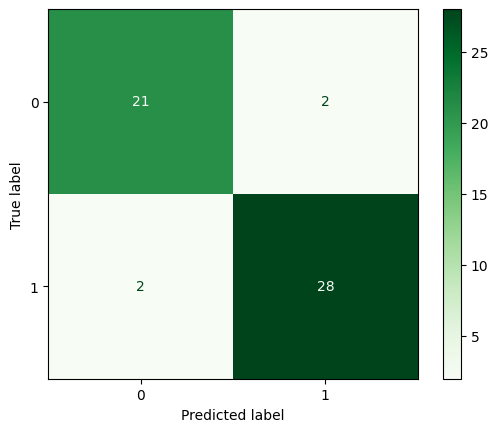

In [48]:
y_pred = final_TF_stop.predict(X_test)
# Predicciones de probabilidad (para ROC AUC)
y_pred_proba = final_TF_stop.predict_proba(X_test)[:, 1]

# --- Calcular las métricas ---
# 1. Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred)

# 2. Reporte de Clasificación (texto)
class_report_str = classification_report(y_test, y_pred)

# 3. Reporte de Clasificación (diccionario para el gráfico)
class_report_dict = classification_report(y_test, y_pred, output_dict=True)

# 4. ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- Imprimir y visualizar las métricas estándar ---
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Área Bajo la Curva ROC (AUC): {roc_auc:.4f}\n")

print(" Reporte de Clasificación:")
print(class_report_str)

print("Matriz de Confusión:")
ConfusionMatrixDisplay.from_estimator(final_TF_stop, X_test, y_test, cmap='Greens')
plt.show()

¿Qué configuración de preprocesamiento produjo mejores resultados?

**R =** Utilizar TF IDF con stop words 

¿Qué combinación de hiperparámetros de vectorización y de la Regresión Logística fue más efectiva?

**R =** C=16.56  y 2000 iteraciones 

¿Qué categorías de noticias resultaron más fáciles/difíciles de clasificar?

**R =** Arte

¿Qué limitaciones detectaste en el modelo?

**R =** Metricas muy buenas para ser verdad quiza hay que probarlo en otro data set